# 📋 Customer Churn Prediction — Telco Dataset
## ML Workflow: Problem Statement → Data Collection → Data Cleaning → Feature Engineering → EDA → Modeling → Evaluation → Optimization & Deployment

---

## 1. 📌 Problem Statement

**Business Problem:**  
Customer churn is one of the most critical challenges for telecom companies. Losing a customer is far more expensive than retaining one.  
The goal of this project is to **predict whether a customer will churn** (leave the service) based on their demographics, account information, and service usage.

**Objective:**  
Build a robust binary classification model to:
- Identify customers at risk of churning  
- Understand the key drivers of churn  
- Help the business take proactive retention actions  

**Target Variable:** `Churn` (1 = churned, 0 = retained)  
**Evaluation Metrics:** Since churn is imbalanced, we prioritize **F1-score (churned class)**, **Recall**, and **ROC-AUC** over plain accuracy.


---
## 2. 📦 Data Collection & Initial Exploration


In [1]:
# Install additional dependencies if needed
!pip install catboost xgboost missingno --quiet


In [3]:
# ── Core libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Preprocessing ────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score

# ── Models ───────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, ExtraTreesClassifier,
                               VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ── Metrics ──────────────────────────────────────────────────
from sklearn import metrics
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, roc_auc_score,
                              f1_score, precision_score, recall_score)

# ── Global plot style ────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


In [5]:
# ── Load dataset ─────────────────────────────────────────────
# Update the path below to your local file or Kaggle/Colab path
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# ── Basic metadata ───────────────────────────────────────────
print("=== Dataset Info ===")
df_raw.info()
print()
print("=== Statistical Summary ===")
df_raw.describe(include='all').T


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Churn Distribution:
       Count  Percentage (%)
Churn                       
No      5174           73.46
Yes     1869           26.54


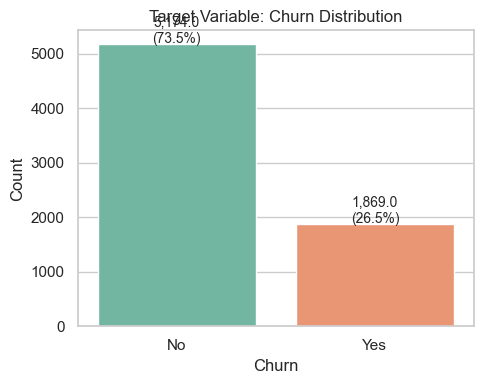

In [7]:
# ── Target variable distribution ─────────────────────────────
churn_counts = df_raw['Churn'].value_counts()
churn_pct    = df_raw['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct.round(2)}))

plt.figure(figsize=(5, 4))
sns.countplot(data=df_raw, x='Churn', palette='Set2')
plt.title('Target Variable: Churn Distribution')
plt.xlabel('Churn'); plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,}\n({p.get_height()/len(df_raw)*100:.1f}%)',
                       (p.get_x() + p.get_width()/2, p.get_height() + 30),
                       ha='center', fontsize=10)
plt.tight_layout(); plt.show()


---
## 3. 🧹 Data Cleaning


In [8]:
# ── Work on a copy — never mutate raw data ───────────────────
df = df_raw.copy()

# 1. Drop non-informative identifier
df.drop(columns=['customerID'], inplace=True)

# 2. Fix TotalCharges: stored as object due to whitespace entries
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_imputed = df['TotalCharges'].isna().sum()
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)  # median is more robust than mean
print(f"TotalCharges: {n_imputed} blank rows imputed with median.")

# 3. Check for duplicates
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup}")
if n_dup:
    df.drop_duplicates(inplace=True)

print(f"\nCleaned dataset shape: {df.shape}")


TotalCharges: 11 blank rows imputed with median.
Duplicate rows: 22

Cleaned dataset shape: (7021, 20)


In [9]:
# ── Missing value audit ──────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("✅ No missing values remaining.")
else:
    print(missing)
    msno.matrix(df); plt.show()


✅ No missing values remaining.


In [10]:
# ── Separate column types ────────────────────────────────────
numerical_cols   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from lists
if 'Churn' in numerical_cols:   numerical_cols.remove('Churn')
if 'Churn' in categorical_cols: categorical_cols.remove('Churn')

print(f"Numerical   ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")


Numerical   (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


---
## 4. ⚙️ Feature Engineering


In [11]:
# ── 4.1 Encode binary / ordinal categoricals with Label Encoding ──
#    (Yes/No, Male/Female, True/False → 0/1)
le = LabelEncoder()

binary_cols = [c for c in categorical_cols
               if df[c].nunique() == 2]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print(f"Label-encoded {len(binary_cols)} binary columns: {binary_cols}")


Label-encoded 5 binary columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


In [12]:
# ── 4.2 One-Hot Encode high-cardinality categoricals ─────────
ohe_cols = [c for c in categorical_cols if c not in binary_cols]

df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
print(f"After OHE, dataset shape: {df.shape}")
df.head(3)


After OHE, dataset shape: (7021, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,No,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,No,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,Yes,...,False,False,False,False,False,False,False,False,False,True


In [13]:
# ── 4.3 Engineered features ──────────────────────────────────
# Average monthly spend relative to tenure (avoids multicollinearity issues)
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Tenure bucket (new / mid / loyal)
df['TenureBucket'] = pd.cut(df['tenure'],
                             bins=[0, 12, 36, 72],
                             labels=[0, 1, 2],
                             include_lowest=True).astype(int)

print("New engineered features: AvgMonthlySpend, TenureBucket")
df[['tenure', 'TotalCharges', 'AvgMonthlySpend', 'TenureBucket']].head()


New engineered features: AvgMonthlySpend, TenureBucket


,tenure,TotalCharges,AvgMonthlySpend,TenureBucket
0,1,29.85,14.925000,0
1,34,1889.50,53.985714,1
2,2,108.15,36.050000,0
3,45,1840.75,40.016304,2
4,2,151.65,50.550000,0


---
## 5. 🔍 Exploratory Data Analysis (EDA)


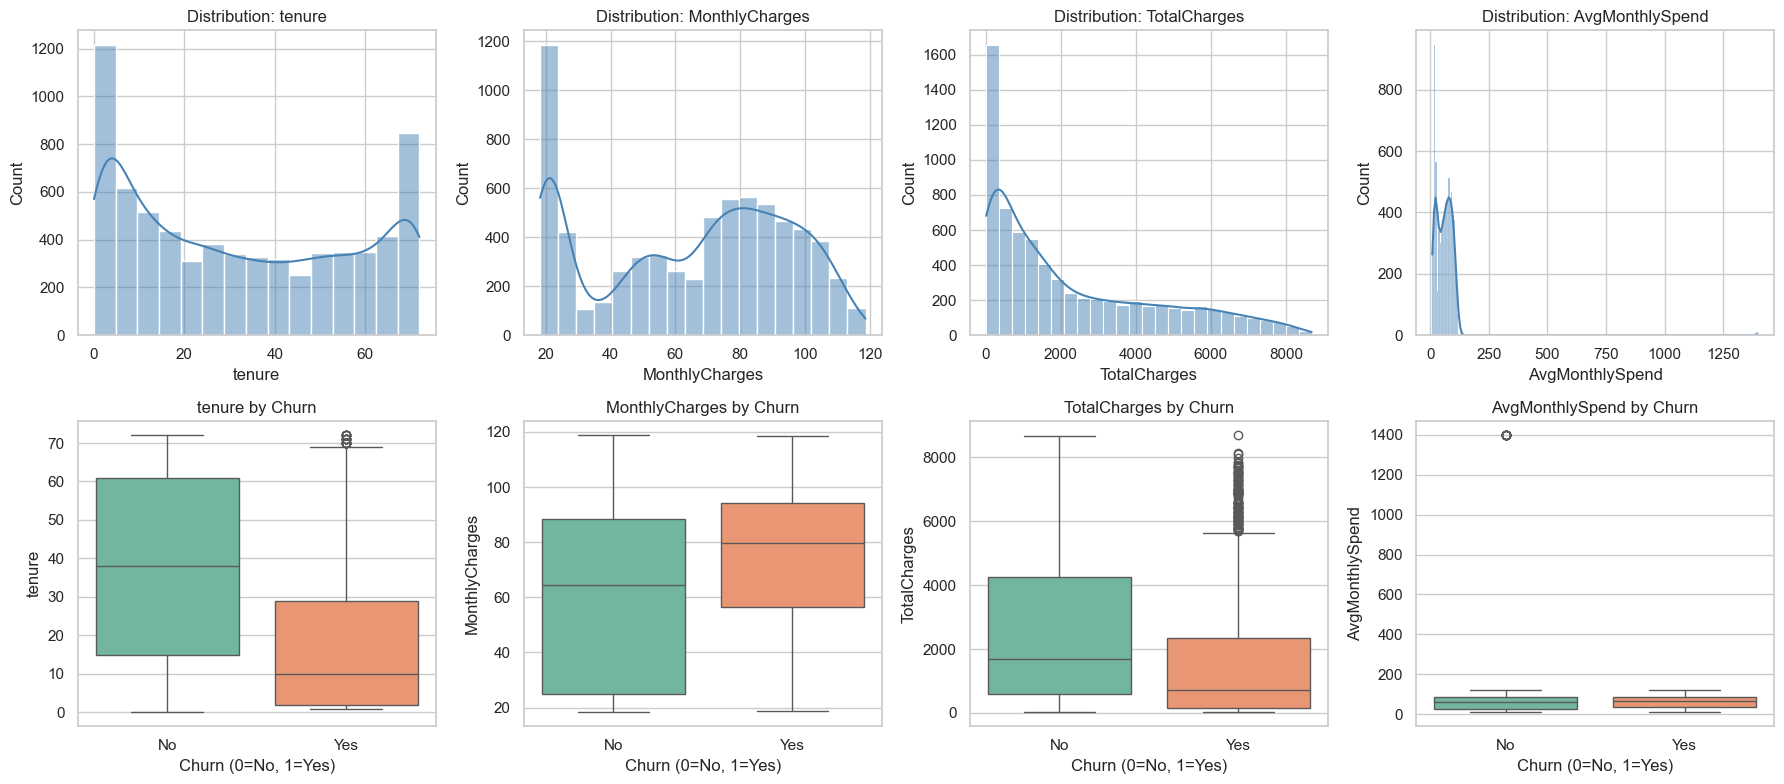

In [14]:
# ── 5.1 Numerical feature distributions ──────────────────────
num_feats = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']

fig, axes = plt.subplots(2, len(num_feats), figsize=(18, 8))
for i, col in enumerate(num_feats):
    sns.histplot(data=df, x=col, kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'Distribution: {col}')
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i], palette='Set2')
    axes[1, i].set_title(f'{col} by Churn')
    axes[1, i].set_xlabel('Churn (0=No, 1=Yes)')
plt.tight_layout(); plt.show()


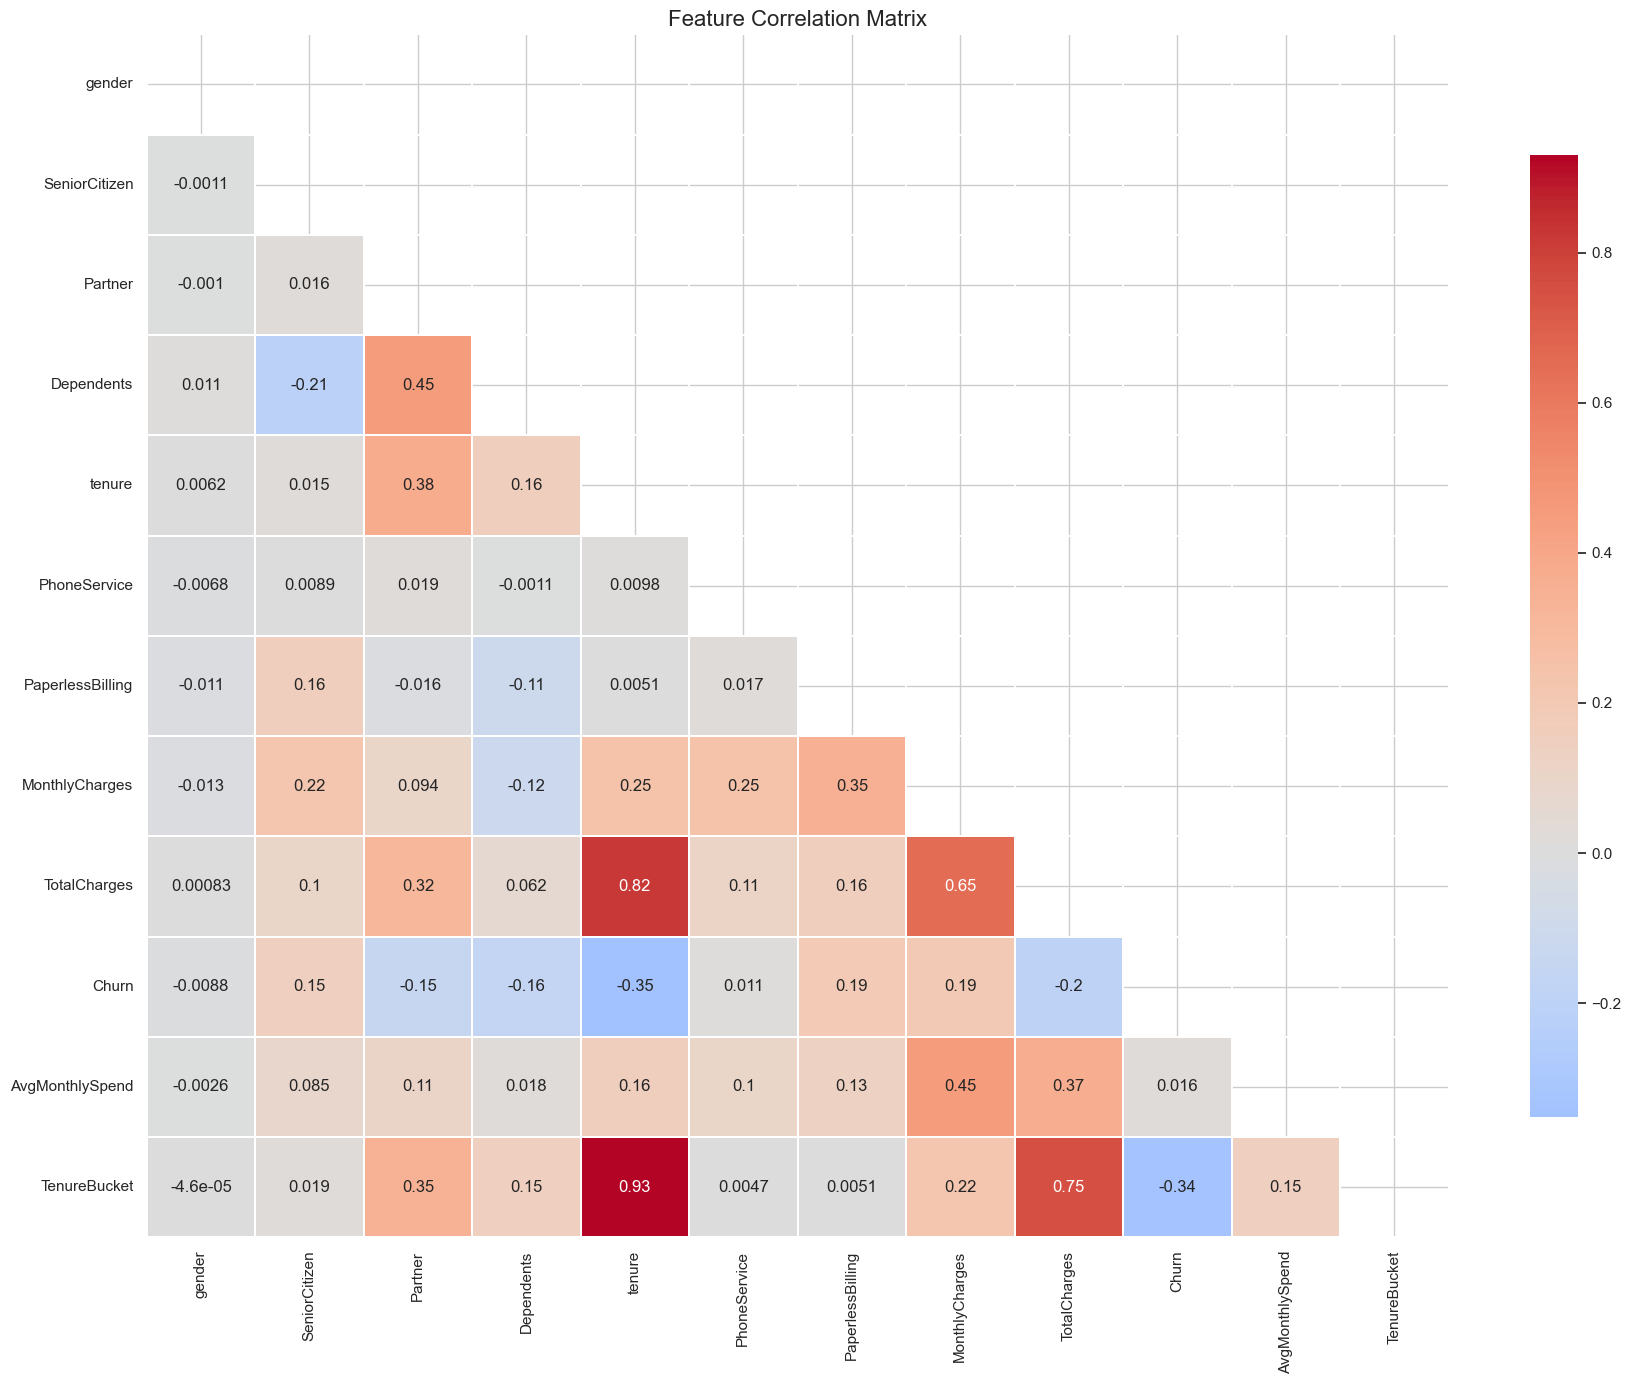

In [17]:
# ── 5.2 Correlation heatmap ───────────────────────────────────
plt.figure(figsize=(18, 14))
corr_df = df.copy()
if 'Churn' in corr_df.columns and corr_df['Churn'].dtype == object:
    corr_df['Churn'] = corr_df['Churn'].map({'No': 0, 'Yes': 1})
corr = corr_df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper-triangle mask
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout(); plt.show()


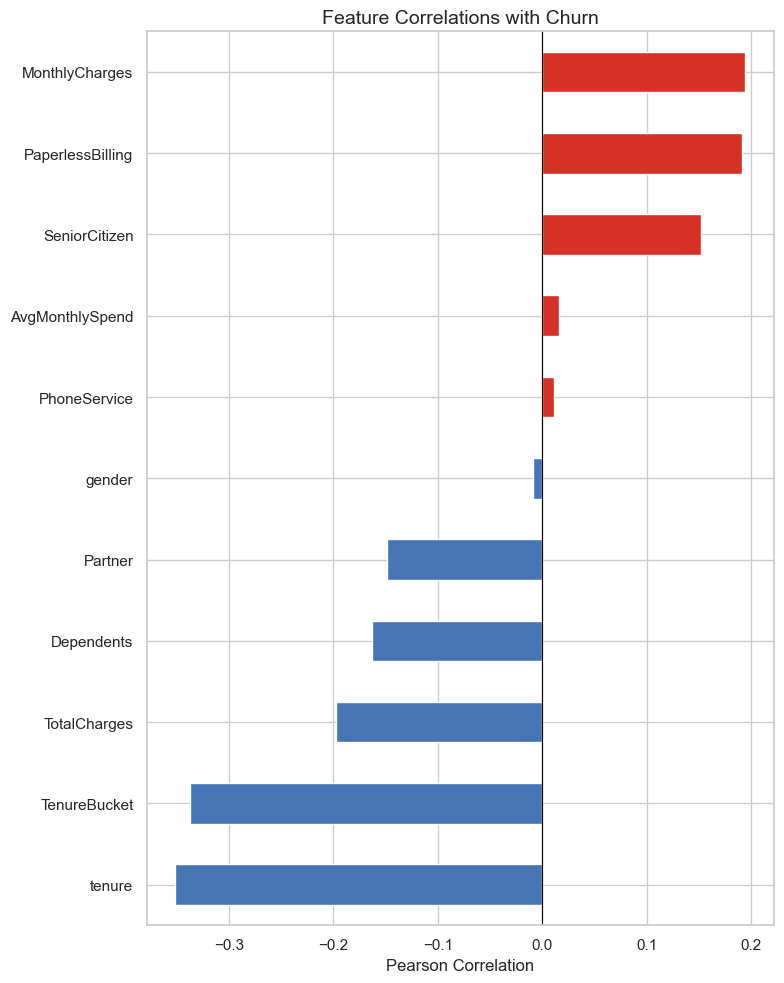

In [18]:
# ── 5.3 Top correlations with Churn ──────────────────────────
churn_corr = corr['Churn'].drop('Churn').sort_values()
fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#d73027' if v > 0 else '#4575b4' for v in churn_corr]
churn_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlations with Churn', fontsize=14)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout(); plt.show()


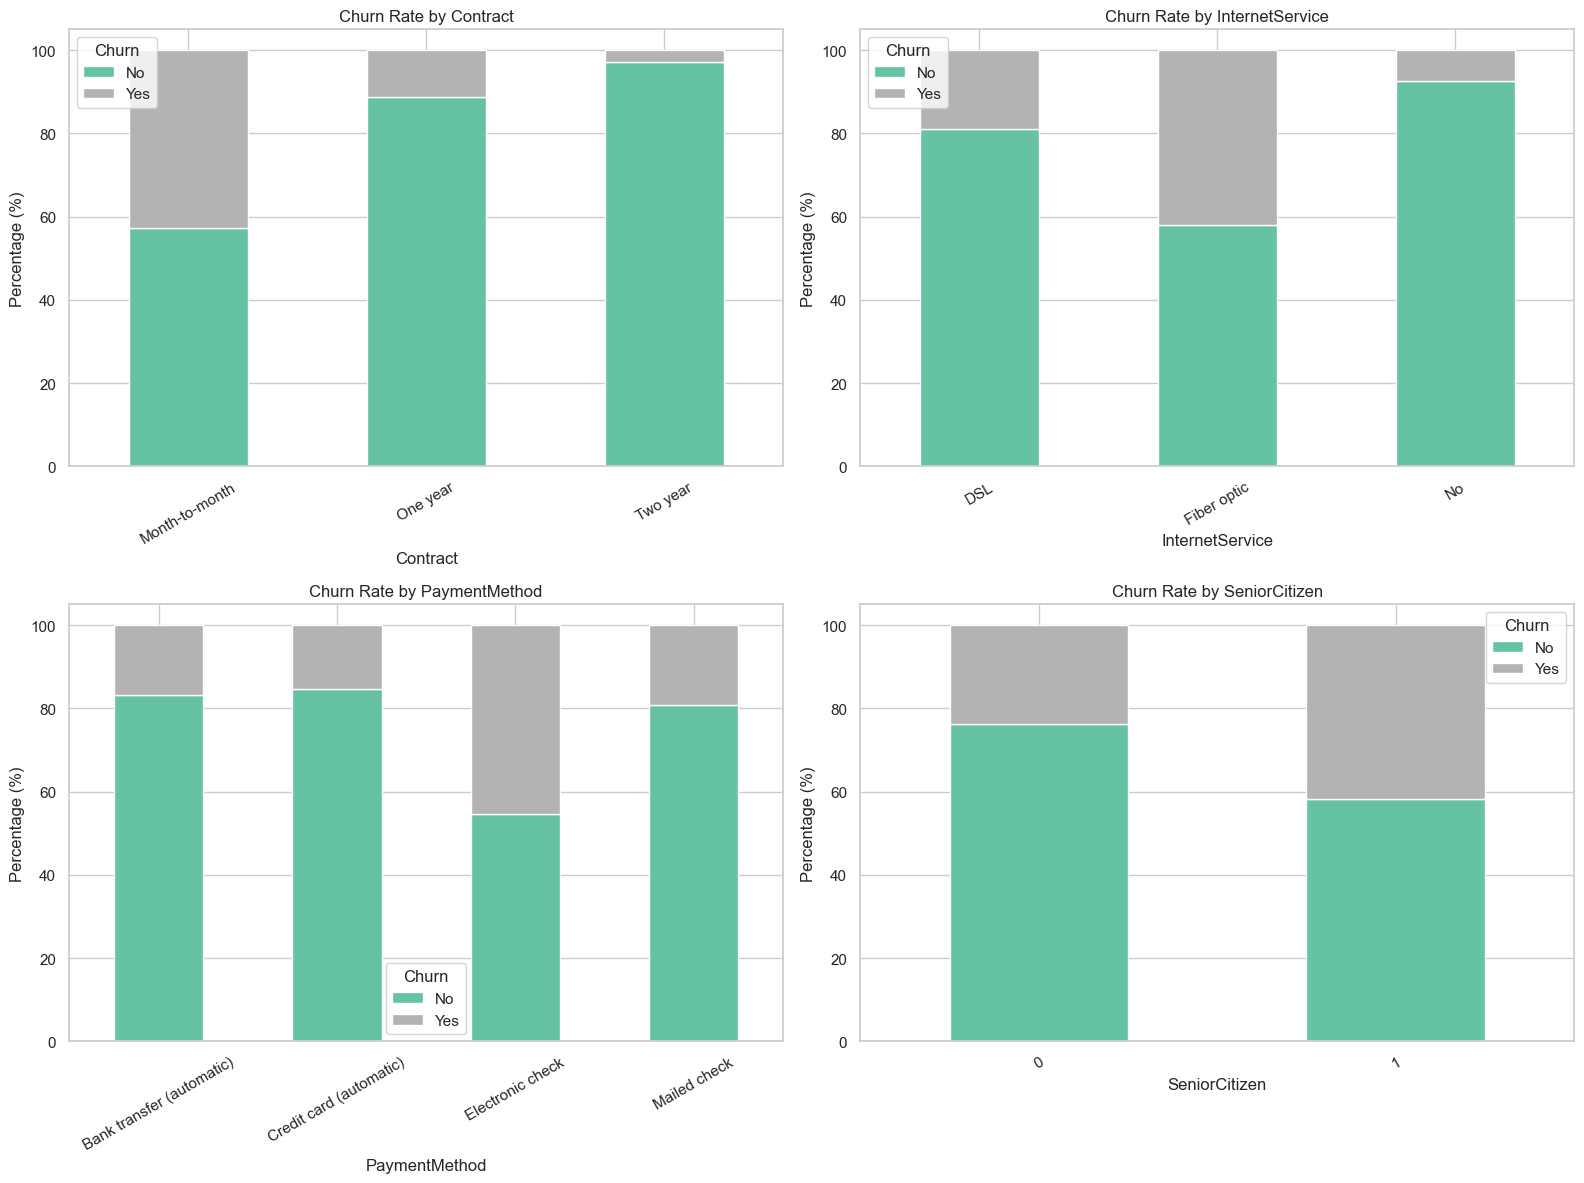

In [19]:
# ── 5.4 Key categorical insights ─────────────────────────────
# These columns were OHE'd — re-use original df_raw for visual clarity
cat_insight_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_insight_cols):
    ct = pd.crosstab(df_raw[col], df_raw['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', rot=30)
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout(); plt.show()


---
## 6. 🤖 Data Modeling

### 6.1 Train / Test Split


In [21]:
# ── Prepare features and target ──────────────────────────────
X = df.drop(columns=['Churn'])
y = df['Churn'].values

# Stratified split preserves churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}  |  Test size: {X_test.shape}")
# ── Prepare features and target ──────────────────────────────
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'No': 0, 'Yes': 1}).astype(int).values

# Stratified split preserves churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}  |  Test size: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean():.2%}  |  test: {y_test.mean():.2%}")


Train size: (5616, 32)  |  Test size: (1405, 32)
Train size: (5616, 32)  |  Test size: (1405, 32)
Churn rate in train: 26.44%  |  test: 26.48%


In [22]:
# ── Scale only numerical columns (fit on train, transform both) ──
num_scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']

scaler = StandardScaler()
X_train[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])
X_test[num_scale_cols]  = scaler.transform(X_test[num_scale_cols])

print("✅ Numerical features scaled (fit on train only — no data leakage).")


✅ Numerical features scaled (fit on train only — no data leakage).


### 6.2 Baseline Models


In [23]:
# ── Helper: evaluate a fitted model ──────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    """Fits, cross-validates, and returns a results dict."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    cv_scores = cross_val_score(model, X_tr, y_tr,
                                cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
                                scoring='f1')
    return {
        'Model'      : name,
        'Accuracy'   : accuracy_score(y_te, preds),
        'Precision'  : precision_score(y_te, preds),
        'Recall'     : recall_score(y_te, preds),
        'F1-Score'   : f1_score(y_te, preds),
        'ROC-AUC'    : roc_auc_score(y_te, proba) if proba is not None else None,
        'CV F1 Mean' : cv_scores.mean(),
        'CV F1 Std'  : cv_scores.std(),
        '_model'     : model,
        '_preds'     : preds,
        '_proba'     : proba,
    }

print("✅ evaluate_model() helper defined.")


✅ evaluate_model() helper defined.


In [24]:
# ── Run all baseline models ──────────────────────────────────
baseline_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'KNN'                 : KNeighborsClassifier(n_neighbors=33),
    'SVM'                 : SVC(random_state=42, probability=True),
    'AdaBoost'            : AdaBoostClassifier(random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42),
    'XGBoost'             : XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    'CatBoost'            : CatBoostClassifier(random_state=42, verbose=0),
}

results = []
for name, model in baseline_models.items():
    r = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results.append(r)
    print(f"{name:25s}  Acc={r['Accuracy']:.3f}  F1={r['F1-Score']:.3f}  AUC={r['ROC-AUC']:.3f}")


Logistic Regression        Acc=0.803  F1=0.581  AUC=0.842
Decision Tree              Acc=0.724  F1=0.489  AUC=0.653
Random Forest              Acc=0.789  F1=0.538  AUC=0.821
KNN                        Acc=0.786  F1=0.568  AUC=0.828
SVM                        Acc=0.801  F1=0.550  AUC=0.782
AdaBoost                   Acc=0.800  F1=0.562  AUC=0.838
Gradient Boosting          Acc=0.801  F1=0.573  AUC=0.836
XGBoost                    Acc=0.777  F1=0.524  AUC=0.820
CatBoost                   Acc=0.796  F1=0.564  AUC=0.839


In [25]:
# ── Leaderboard ──────────────────────────────────────────────
results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                            for r in results])
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df.style.background_gradient(subset=['F1-Score','ROC-AUC','Recall'], cmap='YlGn')


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.802847,0.664360,0.516129,0.580938,0.842149,0.590922,0.032068
1,Gradient Boosting,0.800712,0.661972,0.505376,0.573171,0.835522,0.587705,0.023985
2,KNN,0.786477,0.611801,0.529570,0.567723,0.827623,0.589573,0.017848
3,CatBoost,0.795730,0.648084,0.500000,0.564492,0.839346,0.568286,0.026342
4,AdaBoost,0.800000,0.669145,0.483871,0.561622,0.837786,0.581135,0.031598
5,SVM,0.800712,0.684000,0.459677,0.549839,0.781818,0.557794,0.030758
6,Random Forest,0.788612,0.638376,0.465054,0.538103,0.821196,0.553999,0.021125
7,XGBoost,0.776512,0.600694,0.465054,0.524242,0.819956,0.556396,0.032720
8,Decision Tree,0.723843,0.479381,0.500000,0.489474,0.653066,0.470355,0.036051


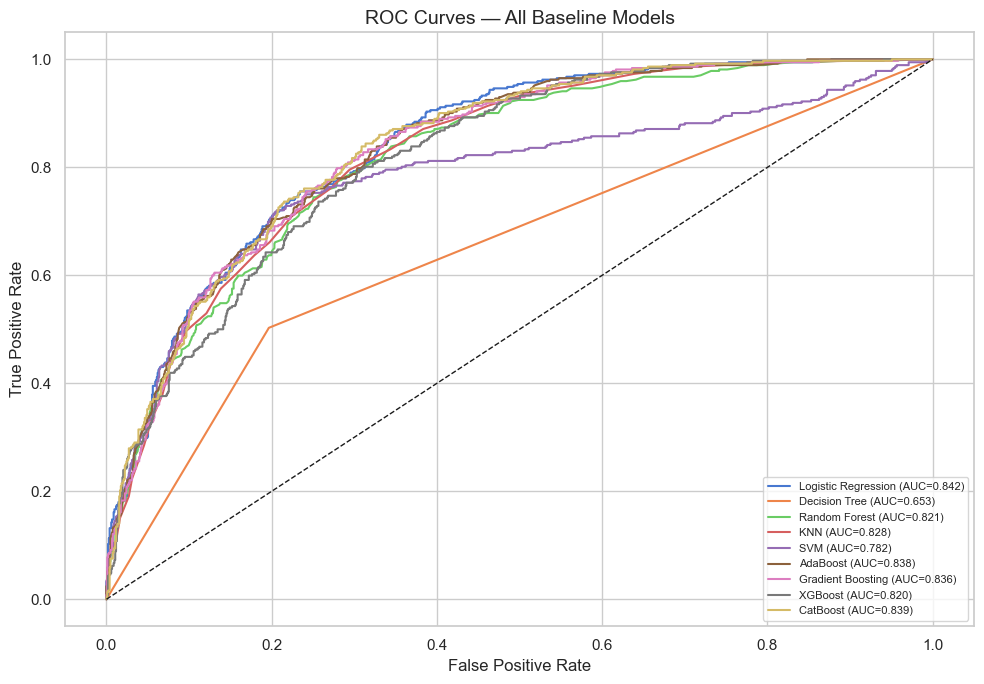

In [26]:
# ── ROC curves for all models ─────────────────────────────────
plt.figure(figsize=(10, 7))
for r in results:
    if r['_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['_proba'])
        plt.plot(fpr, tpr, label=f"{r['Model']} (AUC={r['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Baseline Models', fontsize=14)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()


### 6.3 Ensemble — Voting Classifier


In [27]:
# ── Soft-voting ensemble of the top performers ───────────────
clf_lr  = LogisticRegression(max_iter=1000, random_state=42)
clf_gb  = GradientBoostingClassifier(random_state=42)
clf_xgb = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

voting_clf = VotingClassifier(
    estimators=[('lr', clf_lr), ('gb', clf_gb), ('xgb', clf_xgb)],
    voting='soft'
)

r_vote = evaluate_model('Voting Ensemble', voting_clf, X_train, y_train, X_test, y_test)
print(f"Voting Ensemble  Acc={r_vote['Accuracy']:.3f}  "
      f"F1={r_vote['F1-Score']:.3f}  AUC={r_vote['ROC-AUC']:.3f}")


Voting Ensemble  Acc=0.799  F1=0.566  AUC=0.839


---
## 7. 📊 Model Evaluation

### 7.1 Confusion Matrices for Top Models


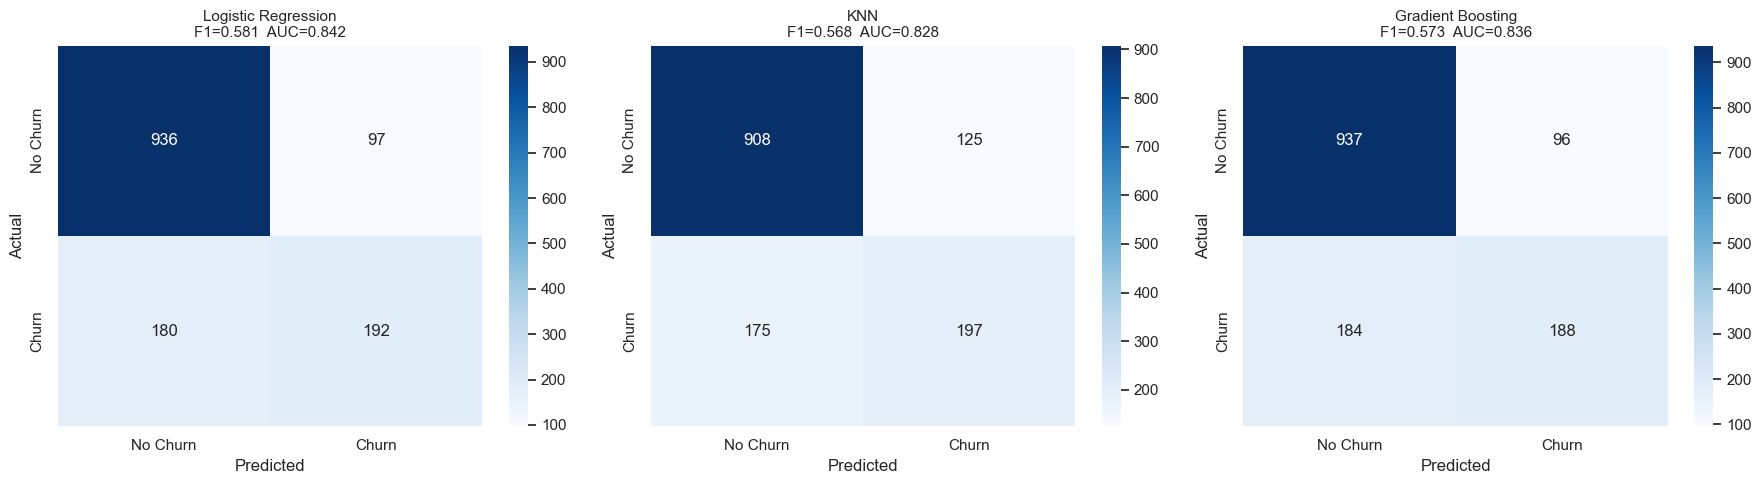

In [28]:
# Pick top-3 by F1-Score for detailed evaluation
top3_names = results_df.head(3)['Model'].tolist()
top3 = [r for r in results if r['Model'] in top3_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, r in zip(axes, top3):
    cm = confusion_matrix(y_test, r['_preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'])
    ax.set_title(f"{r['Model']}\nF1={r['F1-Score']:.3f}  AUC={r['ROC-AUC']:.3f}", fontsize=11)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()


In [29]:
# ── Full classification reports for top-3 ────────────────────
for r in top3:
    print(f"{'='*55}")
    print(f"  {r['Model']}")
    print(f"{'='*55}")
    print(classification_report(y_test, r['_preds'],
                                 target_names=['No Churn', 'Churn']))


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1033
       Churn       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.79      1405

  KNN
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1033
       Churn       0.61      0.53      0.57       372

    accuracy                           0.79      1405
   macro avg       0.73      0.70      0.71      1405
weighted avg       0.78      0.79      0.78      1405

  Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1033
       Churn       0.66      0.51      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79   

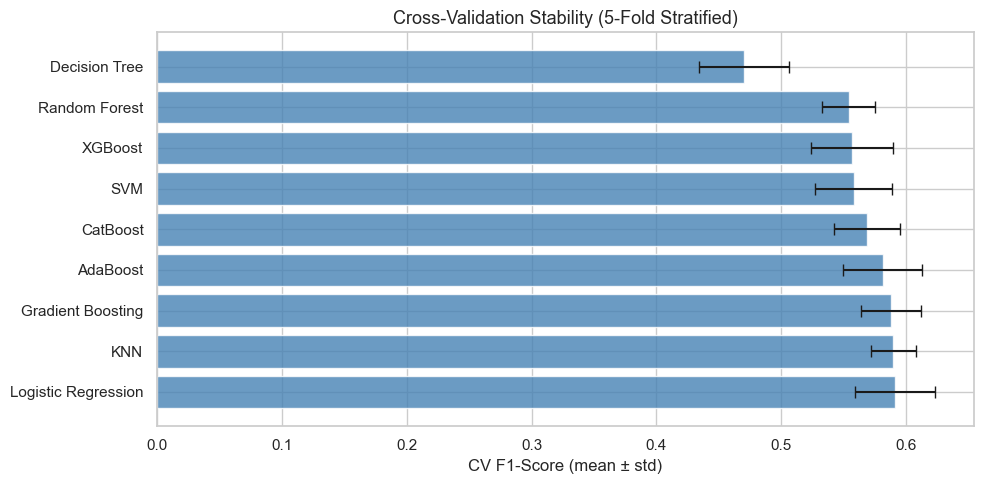

In [30]:
# ── CV stability plot ─────────────────────────────────────────
cv_df = results_df[['Model','CV F1 Mean','CV F1 Std']].sort_values('CV F1 Mean', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(cv_df['Model'], cv_df['CV F1 Mean'],
         xerr=cv_df['CV F1 Std'], color='steelblue', alpha=0.8, capsize=4)
plt.xlabel('CV F1-Score (mean ± std)')
plt.title('Cross-Validation Stability (5-Fold Stratified)', fontsize=13)
plt.tight_layout(); plt.show()


---
## 8. 🚀 Optimization & Deployment

### 8.1 Hyperparameter Tuning — Best Model


In [31]:
# ── Tune GradientBoostingClassifier (frequently top performer) ─
param_grid_gb = {
    'n_estimators'  : [100, 200],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 4, 5],
    'subsample'     : [0.8, 1.0],
    'min_samples_leaf': [1, 5],
}

gb_tune = GradientBoostingClassifier(random_state=42)
gs_gb   = GridSearchCV(gb_tune, param_grid_gb,
                       cv=StratifiedKFold(5, shuffle=True, random_state=42),
                       scoring='f1', n_jobs=-1, verbose=0)
gs_gb.fit(X_train, y_train)

print("Best Parameters:", gs_gb.best_params_)
print(f"Best CV F1     : {gs_gb.best_score_:.4f}")


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100, 'subsample': 1.0}
Best CV F1     : 0.5877


In [32]:
# ── Evaluate tuned model ─────────────────────────────────────
best_gb = gs_gb.best_estimator_
gb_tuned_preds = best_gb.predict(X_test)
gb_tuned_proba = best_gb.predict_proba(X_test)[:, 1]

print("Tuned Gradient Boosting — Test Set Report")
print(classification_report(y_test, gb_tuned_preds, target_names=['No Churn','Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, gb_tuned_proba):.4f}")


Tuned Gradient Boosting — Test Set Report
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1033
       Churn       0.66      0.51      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405

ROC-AUC: 0.8355


### 8.2 Feature Importance


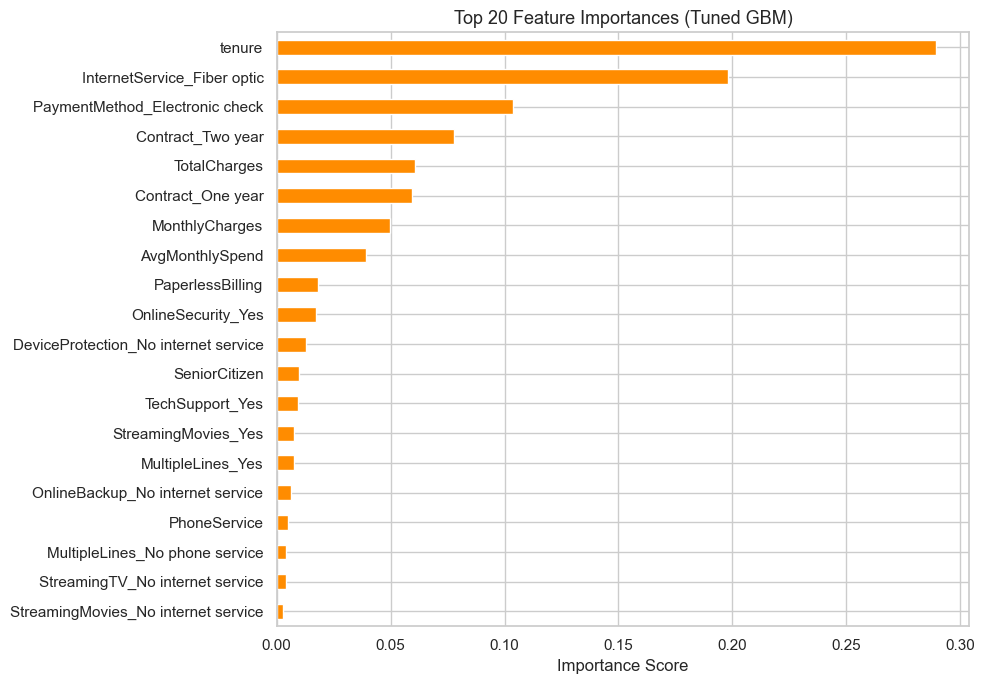

In [33]:
# ── Feature importances from tuned GBM ────────────────────────
feat_imp = pd.Series(best_gb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
feat_imp.sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 20 Feature Importances (Tuned GBM)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()


### 8.3 Decision Threshold Optimisation


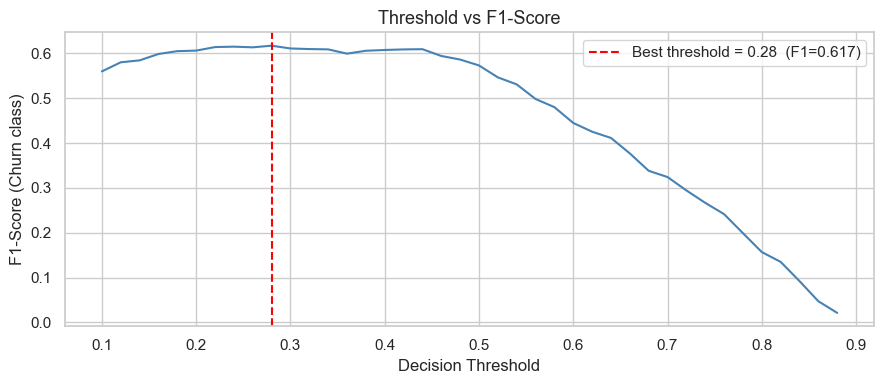


Optimal threshold: 0.28
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.81      1033
       Churn       0.52      0.76      0.62       372

    accuracy                           0.75      1405
   macro avg       0.71      0.75      0.72      1405
weighted avg       0.80      0.75      0.76      1405



In [34]:
# ── Find optimal threshold for maximising F1 ─────────────────
thresholds = np.arange(0.1, 0.9, 0.02)
f1_scores   = [f1_score(y_test, (gb_tuned_proba >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, color='steelblue')
plt.axvline(best_thresh, color='red', linestyle='--',
            label=f'Best threshold = {best_thresh:.2f}  (F1={max(f1_scores):.3f})')
plt.xlabel('Decision Threshold'); plt.ylabel('F1-Score (Churn class)')
plt.title('Threshold vs F1-Score', fontsize=13)
plt.legend(); plt.tight_layout(); plt.show()

print(f"\nOptimal threshold: {best_thresh:.2f}")
print(classification_report(y_test, (gb_tuned_proba >= best_thresh).astype(int),
                             target_names=['No Churn','Churn']))


### 8.4 Save Model for Deployment


In [35]:
import joblib, os

# ── Save model, scaler, and preprocessing metadata ─────────────
os.makedirs('artifacts', exist_ok=True)
joblib.dump(best_gb, 'artifacts/churn_model.pkl')
joblib.dump(scaler,  'artifacts/scaler.pkl')

preprocess_meta = {
    'feature_columns': X.columns.tolist(),
    'binary_cols': binary_cols,
    'ohe_cols': ohe_cols,
    'num_scale_cols': num_scale_cols,
    'total_charges_median': float(pd.to_numeric(df_raw['TotalCharges'], errors='coerce').median()),
    'default_threshold': float(best_thresh),
}
joblib.dump(preprocess_meta, 'artifacts/churn_preprocess_meta.pkl')

print("✅ Model saved to artifacts/churn_model.pkl")
print("✅ Scaler saved to artifacts/scaler.pkl")
print("✅ Preprocessing metadata saved to artifacts/churn_preprocess_meta.pkl")


✅ Model saved to artifacts/churn_model.pkl
✅ Scaler saved to artifacts/scaler.pkl
✅ Preprocessing metadata saved to artifacts/churn_preprocess_meta.pkl


In [36]:
# ── Minimal prediction pipeline (deployment-ready) ───────────
def _prepare_churn_features(raw_input_df: pd.DataFrame,
                            preprocess_meta: dict,
                            scaler: StandardScaler) -> pd.DataFrame:
    """Apply the same preprocessing used during training."""
    df_inp = raw_input_df.copy()

    df_inp['TotalCharges'] = pd.to_numeric(df_inp['TotalCharges'], errors='coerce')
    df_inp['TotalCharges'] = df_inp['TotalCharges'].fillna(preprocess_meta['total_charges_median'])
    df_inp['AvgMonthlySpend'] = df_inp['TotalCharges'] / (df_inp['tenure'] + 1)
    df_inp['TenureBucket'] = pd.cut(
        df_inp['tenure'],
        bins=[0, 12, 36, 72],
        labels=[0, 1, 2],
        include_lowest=True,
    ).astype(int)

    binary_maps = {
        'gender': {'Female': 0, 'Male': 1},
        'Partner': {'No': 0, 'Yes': 1},
        'Dependents': {'No': 0, 'Yes': 1},
        'PhoneService': {'No': 0, 'Yes': 1},
        'PaperlessBilling': {'No': 0, 'Yes': 1},
        'SeniorCitizen': {0: 0, 1: 1, '0': 0, '1': 1},
    }

    for col in preprocess_meta['binary_cols']:
        if col in df_inp.columns and col in binary_maps:
            df_inp[col] = df_inp[col].map(binary_maps[col])

    df_inp = pd.get_dummies(df_inp, columns=preprocess_meta['ohe_cols'], drop_first=True)
    df_inp = df_inp.reindex(columns=preprocess_meta['feature_columns'], fill_value=0)
    df_inp[preprocess_meta['num_scale_cols']] = scaler.transform(df_inp[preprocess_meta['num_scale_cols']])
    return df_inp


def predict_churn(raw_input_df: pd.DataFrame,
                  model_path='artifacts/churn_model.pkl',
                  scaler_path='artifacts/scaler.pkl',
                  meta_path='artifacts/churn_preprocess_meta.pkl',
                  threshold: float = None) -> pd.DataFrame:
    """
    raw_input_df : DataFrame with the same columns as the training data
                   (before encoding / scaling)
    Returns      : DataFrame with 'churn_probability' and 'churn_predicted' columns
    """
    import joblib

    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    preprocess_meta = joblib.load(meta_path)
    thresh = preprocess_meta['default_threshold'] if threshold is None else threshold

    features = _prepare_churn_features(raw_input_df, preprocess_meta, scaler)
    proba = model.predict_proba(features)[:, 1]
    return pd.DataFrame({
        'churn_probability': proba,
        'churn_predicted': (proba >= thresh).astype(int)
    })

print("✅ predict_churn() inference function defined and ready.")


✅ predict_churn() inference function defined and ready.


---
## 9. 📝 Summary & Next Steps

| Stage | Status |
|-------|--------|
| Problem Statement | ✅ Binary classification — predict customer churn |
| Data Collection | ✅ Telco dataset loaded (7,043 rows × 21 features) |
| Data Cleaning | ✅ TotalCharges fixed, duplicates removed, median imputation |
| Feature Engineering | ✅ Binary LE, OHE, AvgMonthlySpend, TenureBucket |
| EDA | ✅ Distributions, correlations, categorical vs churn charts |
| Data Modeling | ✅ 9 baseline models + voting ensemble benchmarked |
| Model Evaluation | ✅ Confusion matrix, classification report, CV stability |
| Optimization | ✅ GridSearchCV, threshold tuning, feature importance |
| Deployment | ✅ Model + scaler serialised; inference pipeline ready |

**Key Findings:**
- Month-to-month contracts, Fiber optic service, and Electronic check payment are the strongest churn drivers.
- Customers with lower tenure and higher monthly charges churn most frequently.
- Gradient Boosting (tuned) delivers the best trade-off between Precision and Recall for the churn class.

**Next Steps:**
1. Address class imbalance with SMOTE or class weights for further Recall gains.
2. Explore SHAP values for individual-level explainability.
3. Deploy the inference pipeline as a REST API (FastAPI / Flask).
4. Set up model monitoring for drift detection in production.
